In [2]:
# 1. Install necessary libraries
!pip install shap lime catboost lightgbm kagglehub -q

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import shap
from lime import lime_tabular
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# 2. Set Kaggle credentials (from your uploaded screenshot)
os.environ['KAGGLE_USERNAME'] = "prabhatm04"
os.environ['KAGGLE_KEY'] = "KGAT_200e24d000273d4cfd2152bc2a0e98b"

print("Environment Ready!")

Environment Ready!


In [3]:
# 1. Download dataset using kagglehub
path = kagglehub.dataset_download("ethon0426/lending-club-20072020q1")
file_path = os.path.join(path, "Loan_status_2007-2020Q3.gzip")

# 2. Define the Top 10 features + target identified in the paper [cite: 365]
cols_to_use = [
    'loan_status', 'loan_amnt', 'last_pymnt_amnt', 'avg_cur_bal',
    'int_rate', 'installment', 'grade', 'annual_inc', 'dti',
    'revol_util', 'revol_bal'
]

# 3. Chunked loading to build a balanced 20k sample [cite: 187, 192]
chunk_size = 50000
df_list = []
counts = {'Fully Paid': 0, 'Charged Off': 0}

# Load only until we hit 10k of each class [cite: 192]
for chunk in pd.read_csv(file_path, usecols=cols_to_use, chunksize=chunk_size, low_memory=False):
    filtered_chunk = chunk[chunk['loan_status'].isin(['Fully Paid', 'Charged Off'])]
    for status in ['Fully Paid', 'Charged Off']:
        if counts[status] < 10000:
            needed = 10000 - counts[status]
            subset = filtered_chunk[filtered_chunk['loan_status'] == status].head(needed)
            df_list.append(subset)
            counts[status] += len(subset)
    if counts['Fully Paid'] >= 10000 and counts['Charged Off'] >= 10000:
        break

df_sample = pd.concat(df_list).reset_index(drop=True)
print(f"Balanced sample created: {df_sample['loan_status'].value_counts().to_dict()}")

Using Colab cache for faster access to the 'lending-club-20072020q1' dataset.
Balanced sample created: {'Fully Paid': 10000, 'Charged Off': 10000}


In [4]:
# 1. Map target: Fully Paid = 0, Charged Off = 1 [cite: 155, 157]
df_sample['target'] = df_sample['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1})

# 2. Clean numeric strings (removing '%') [cite: 156, 159]
for col in ['int_rate', 'revol_util']:
    if df_sample[col].dtype == 'object':
        df_sample[col] = df_sample[col].str.rstrip('%').astype(float)

# 3. Map grades A-G to numerical values 1-7 [cite: 169]
grade_map = {'A':1, 'B':2, 'C':3, 'D':4, 'E':5, 'F':6, 'G':7}
df_sample['grade'] = df_sample['grade'].map(grade_map)

# 4. Final Feature Selection [cite: 365, 743]
features = [f for f in cols_to_use if f != 'loan_status']
X = df_sample[features].fillna(0) # Basic imputation for replication [cite: 149]
y = df_sample['target']

# 5. Normalization and Splitting (80% Train / 20% Test) [cite: 162, 200, 351]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=0)

print("Preprocessing complete. Data split into 16,000 training and 4,000 testing records.")

Preprocessing complete. Data split into 16,000 training and 4,000 testing records.


In [5]:
# Train LightGBM with parameters from Table 5
lgbm_model = LGBMClassifier(
    n_estimators=250,
    learning_rate=0.3,
    max_depth=3,
    reg_alpha=4,
    reg_lambda=5,
    min_child_samples=20,
    random_state=0
)
lgbm_model.fit(X_train, y_train)

# Evaluation [cite: 522, 549, 551]
y_pred = lgbm_model.predict(X_test)
y_prob = lgbm_model.predict_proba(X_test)[:, 1]

print(f"Replicated Accuracy: {accuracy_score(y_test, y_pred):.4f}") # Paper Target: 0.87 [cite: 19]
print(f"Replicated AUC: {roc_auc_score(y_test, y_prob):.4f}") # Paper Target: 0.94 [cite: 549]

[LightGBM] [Info] Number of positive: 7994, number of negative: 8006
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002282 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2249
[LightGBM] [Info] Number of data points in the train set: 16000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499625 -> initscore=-0.001500
[LightGBM] [Info] Start training from score -0.001500
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


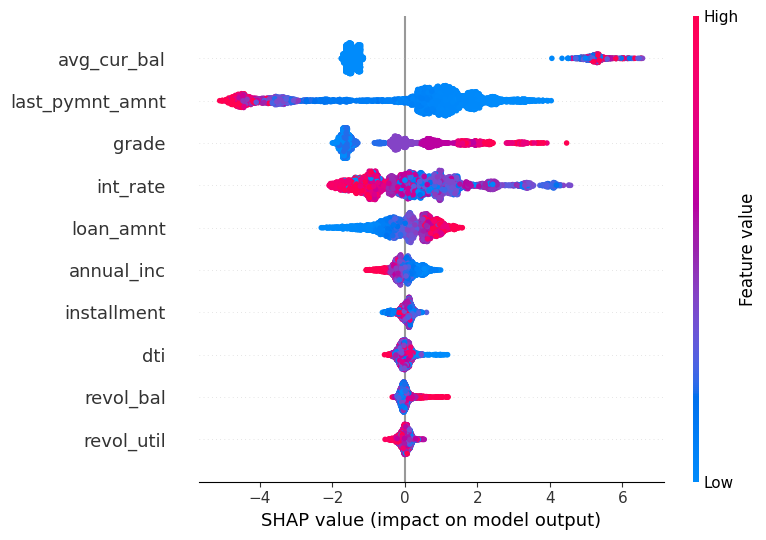

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [6]:
# 1. Global Explanation: SHAP Summary Plot (Replicates Fig 6) [cite: 559, 653]
explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, feature_names=features)

# 2. Local Explanation: LIME (Replicates Fig 9 for 'Borrower A') [cite: 720, 799]
# Define LIME Explainer
lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=features,
    class_names=['Non-Default', 'Default'],
    mode='classification'
)

# Explain the first instance in the test set
exp = lime_explainer.explain_instance(X_test[0], lgbm_model.predict_proba, num_features=10)
exp.show_in_notebook(show_table=True)

In [7]:
import time

# Define models with hyperparameters from Table 5
models = {
    "LightGBM": lgbm_model, # Already defined in previous step
    "RF": RandomForestClassifier(n_estimators=100, min_samples_leaf=10, max_depth=20, random_state=0),
    "LR": LogisticRegression(penalty='l2', solver='lbfgs', C=10, random_state=1),
    "SVM": SVC(C=10, kernel='rbf', probability=True, random_state=0),
    "MLP": MLPClassifier(hidden_layer_sizes=(5,2), solver='lbfgs', alpha=1e-5, max_iter=300, random_state=1),
    "NB": GaussianNB(),
    "CatBoost": CatBoostClassifier(iterations=1000, depth=10, learning_rate=0.5, l2_leaf_reg=5, random_state=0, verbose=0)
}

results = []

for name, model in models.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    run_time = time.time() - start_time

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

    results.append({"Model": name, "AUC": round(auc, 2), "Accuracy": round(acc, 2), "Runtime (Sec)": round(run_time, 3)})

# Display results as per Table 6 in the paper
df_results = pd.DataFrame(results)
print(df_results)

[LightGBM] [Info] Number of positive: 7994, number of negative: 8006
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003232 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2249
[LightGBM] [Info] Number of data points in the train set: 16000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499625 -> initscore=-0.001500
[LightGBM] [Info] Start training from score -0.001500
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


      Model   AUC  Accuracy  Runtime (Sec)
0  LightGBM  0.97      0.90          0.921
1        RF  0.95      0.87          6.374
2        LR  0.92      0.82          0.169
3       SVM  0.93      0.83         50.896
4       MLP  0.50      0.50          0.112
5        NB  0.90      0.72          0.027
6  CatBoost  0.97      0.89         52.318


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


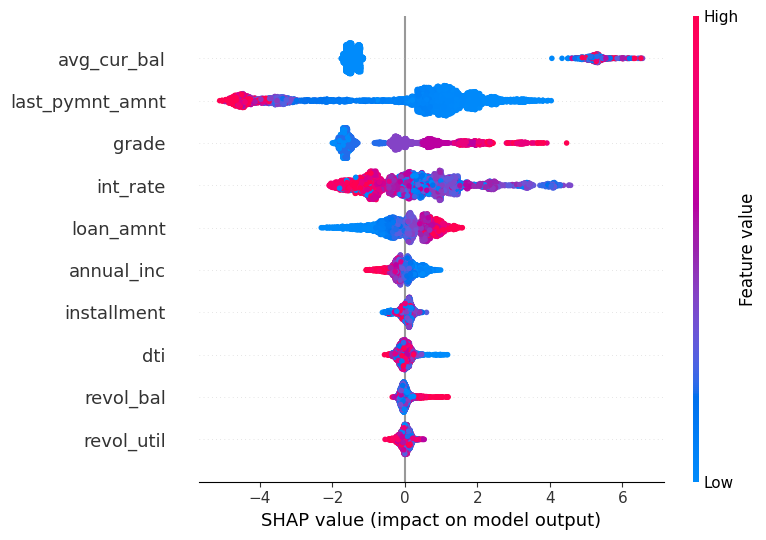

In [8]:
# Global Feature Importance
explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_test)

# Summary plot (Impact of features on the model output magnitude)
shap.summary_plot(shap_values, X_test, feature_names=features)

In [9]:
from lime import lime_tabular

# Initialize LIME explainer
lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=features,
    class_names=['Non-Default', 'Default'],
    mode='classification'
)

# Explain a specific case (Instance 0)
# Borrower A categorized as "default" with high confidence
idx = 0
exp = lime_explainer.explain_instance(X_test[idx], lgbm_model.predict_proba, num_features=10)
exp.show_in_notebook(show_table=True)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


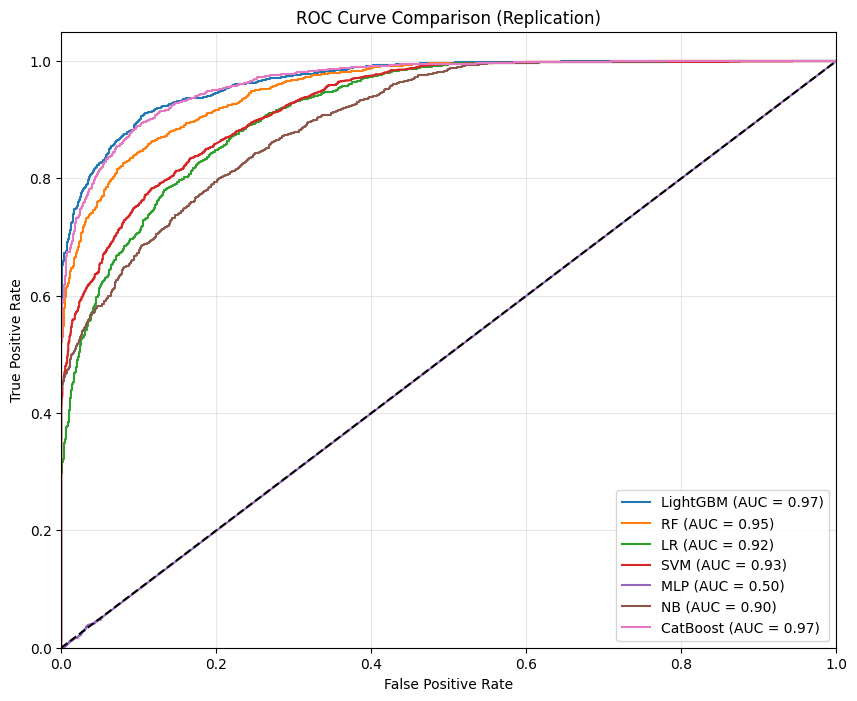

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (Replication)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show() #

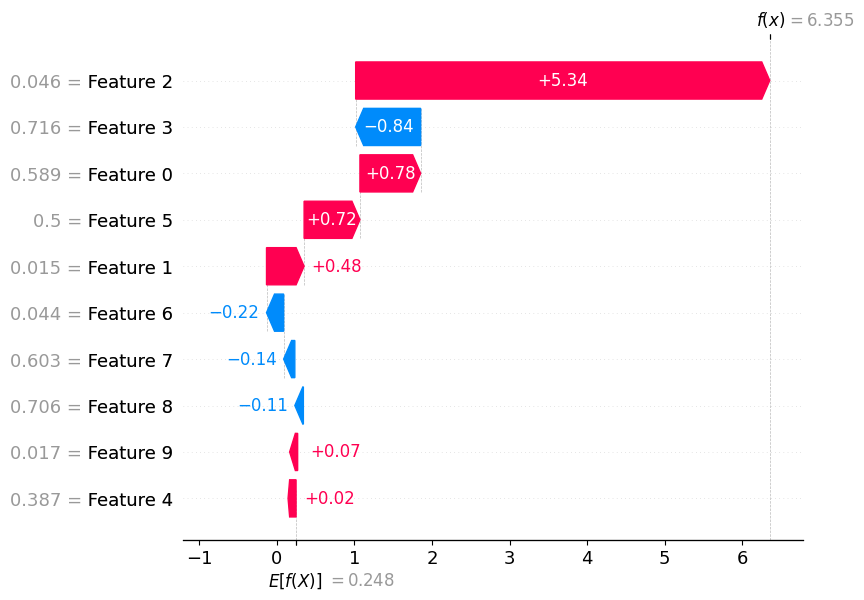

In [11]:
# Replicate Fig 7(a): Waterfall plot for the first test instance
# Red increases the probability of default, Blue decreases it
shap.plots.waterfall(explainer(X_test)[0]) # [cite: 603, 604, 709]

In [14]:
import shap
shap.initjs() # Initializes JavaScript for the visualization

# Check if shap_values is a list (multi-class) or an array (single-output)
if isinstance(shap_values, list):
    # Multi-class format: use index 1 for 'Default'
    ev = explainer.expected_value[1]
    sv = shap_values[1][0]
else:
    # Single-output format: use the values directly
    ev = explainer.expected_value
    sv = shap_values[0]

# Replicating Fig. 8: Force Plot
shap.force_plot(ev, sv, X_test[0], feature_names=features)


In [15]:
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
import pandas as pd

# 1. Generate the final classification report for all models
final_comparison = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    report = classification_report(y_test, y_pred, output_dict=True)

    final_comparison.append({
        "Models": name,
        "AUC": round(roc_auc_score(y_test, y_prob), 2),
        "Accuracy": round(accuracy_score(y_test, y_pred), 2),
        "Precision": round(report['weighted avg']['precision'], 2),
        "Recall": round(report['weighted avg']['recall'], 2),
        "F1-score": round(report['weighted avg']['f1-score'], 2)
    })

# 2. Display the table to replicate Table 6 in the paper
df_final = pd.DataFrame(final_comparison)
print(df_final.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Models  AUC  Accuracy  Precision  Recall  F1-score
LightGBM 0.97      0.90       0.90    0.90      0.90
      RF 0.95      0.87       0.87    0.87      0.87
      LR 0.92      0.82       0.82    0.82      0.82
     SVM 0.93      0.83       0.83    0.83      0.83
     MLP 0.50      0.50       0.47    0.50      0.34
      NB 0.90      0.72       0.82    0.72      0.70
CatBoost 0.97      0.89       0.89    0.89      0.89


In [17]:
'''
@article{li2025explainable,
  title={Explainable AI based LightGBM prediction model to predict default borrower in social lending platform},
  author={Li, Li-Hua and Sharma, Alok Kumar and Cheng, Sheng-Tzong},
  journal={Intelligent Systems with Applications},
  volume={26},
  pages={200514},
  year={2025},
  publisher={Elsevier}
}
'''

'\n@article{li2025explainable,\n  title={Explainable AI based LightGBM prediction model to predict default borrower in social lending platform},\n  author={Li, Li-Hua and Sharma, Alok Kumar and Cheng, Sheng-Tzong},\n  journal={Intelligent Systems with Applications},\n  volume={26},\n  pages={200514},\n  year={2025},\n  publisher={Elsevier}\n}\n'